# TP 2 - CNN for cells classification

#  Erwan Ouabdesselam

In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import functools as ft
from sklearn.model_selection import train_test_split
from PIL import Image
from pandas.plotting import scatter_matrix
import seaborn as sns
from sklearn.metrics import accuracy_score
from torch.utils.data.sampler import WeightedRandomSampler
from sklearn.metrics import confusion_matrix, classification_report
from pylab import rcParams
import torch.optim as optim
#from google.colab import drive
import torchvision
import torch.nn.functional as F
from sklearn.preprocessing import LabelEncoder
import torch.nn as nn
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch
from torchvision.models import resnet50, ResNet50_Weights


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [2]:
def plot_confusion(prediction, target):
    '''
    plot correlation's matrix to explore dependency between features
    '''
    # init figure size
    list_labels_cat = ['ARTEFACTS',
          'BASOPHILES',
          'BLASTES',
          'EOSINOPHILES',
          'ERYTHROBLASTES',
          'LYMPHOCYTES',
          'METAMYELOCYTES',
          'MONOCYTES',
          'MYELOCYTES',
          'NEUTROPHILES',
          'PROMYELOCYTES']
    targ_valids_cat = [list_labels_cat[i] for i in target]
    preds_valids_cat = [list_labels_cat[i] for i in prediction]
    rcParams['figure.figsize'] = 7, 7
    df = pd.DataFrame(confusion_matrix(targ_valids_cat, preds_valids_cat, labels = list_labels_cat, normalize='true'), index = list_labels_cat, columns= list_labels_cat)
    # df = pd.DataFrame(confusion_matrix(targ_valids_cat, preds_valids_cat, labels = list_labels_cat, normalize = 'true'))

    fig = plt.figure()
    sns.heatmap(df, annot=True, fmt=".2f")
    plt.show()
    fig.savefig('corr.png')



# Import features

# Understanding an image with Python

Our images are 250x250x3 numpy matrices.

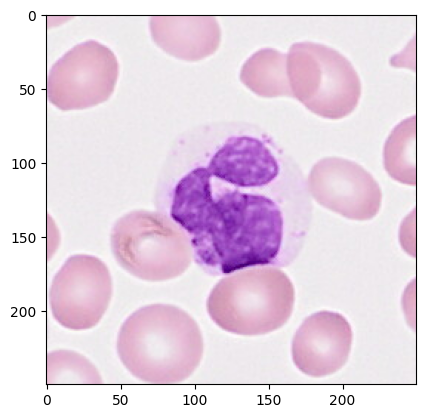

In [3]:
image = Image.open('allImages_247_282/image1.png').convert('RGB')
image = np.array(image)
plt.imshow(image)

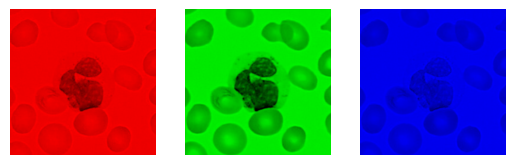

In [4]:
figure, plots = plt.subplots(ncols=3, nrows=1)
for i, subplot in zip(range(3), plots):
    temp = np.zeros(image.shape, dtype='uint8')
    temp[:,:,i] = image[:,:,i]
    subplot.imshow(temp)
    subplot.set_axis_off()
plt.show()

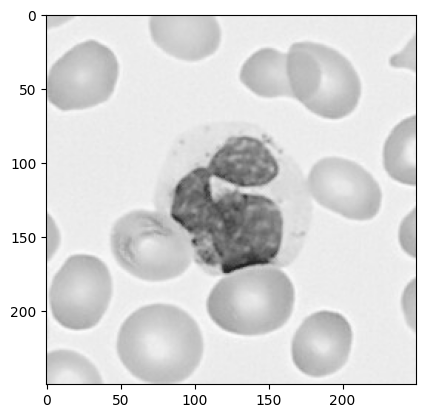

In [5]:
image_grey = Image.open('allImages_247_282/image1.png').convert('LA')
plt.imshow(image_grey)

# Image transformations

1. Using transforms package, apply the following transformations to *image*:




*   Transform from image to tensor
*   Normalize image so that all pixel values are between 0 and 1, with 0.5 mean and 0.5 standard deviation
*   Crop image
*   Put a random horizontal flip
*   Jitter the colour of the image
*   Add a gaussian blur


Remark: you can use `transforms.Compose` to use several transformations at the same time.


Examples of expected results:

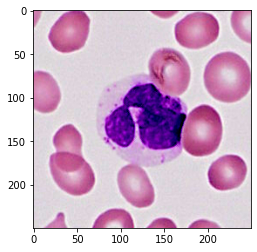


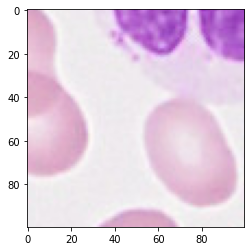

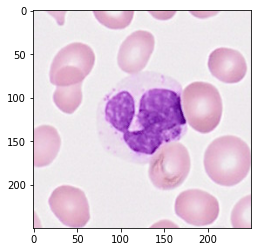

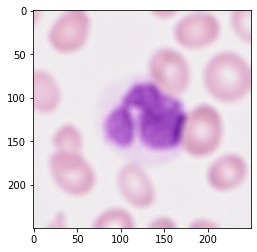



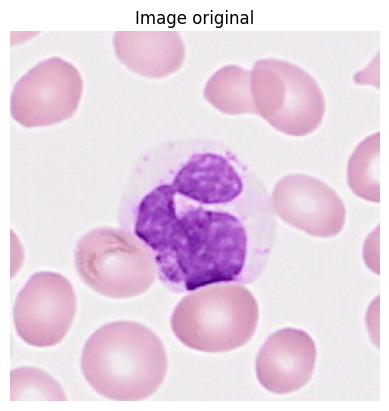

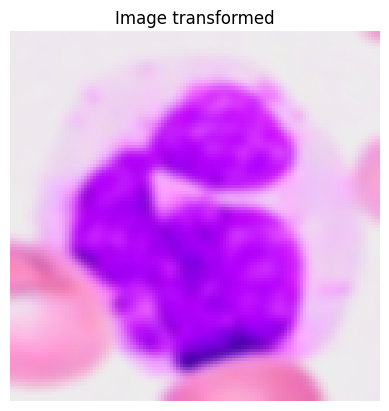

In [6]:
# Answer

image = Image.open('allImages_247_282/image1.png').convert('RGB')

transform = transforms.Compose([
    transforms.CenterCrop(120),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.4, contrast=0.8, saturation=0.8),
    transforms.GaussianBlur(kernel_size=11),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

image_transformed = transform(image)

# show original
plt.imshow(np.array(image))
plt.title("Image original")
plt.axis("off")
plt.show()

# undo normalization for display
img = image_transformed.permute(1,2,0)
img = img * 0.5 + 0.5

plt.imshow(img)
plt.title("Image transformed")
plt.axis("off")
plt.show()

# Add labels

In [7]:
labels = pd.read_csv('labels.csv')

In [8]:
labels['label'].value_counts()

label
ERYTHROBLASTES    1324
NEUTROPHILES       760
LYMPHOCYTES        357
ARTEFACTS          237
MONOCYTES          162
BLASTES             93
MYELOCYTES          78
BASOPHILES          69
METAMYELOCYTES      46
EOSINOPHILES         7
PROMYELOCYTES        7
Name: count, dtype: int64

## Labels encoding



2. a. Use the `LabelEncoder() `to convert categorical labels to numbers.

   b. Use `train_test_split` to split the dataset into 2 subdataframes `train` and `test` (test_size = 0.2, random_state = 42)


In [9]:
print(labels.columns)

Index(['Unnamed: 0', 'cytoID', 'label'], dtype='str')


In [10]:
#Answer
X=labels["cytoID"]
#a
le=LabelEncoder()

labels['label_encoded'] = le.fit_transform(labels['label'])

y=labels['label_encoded']
#b
train_df, test_df = train_test_split(
    labels,
    test_size=0.2,
    random_state=42
)

# Create dataloader

You will now have to create 2 dataloaders, `dataloader_train` and `dataloader_test` that will generate batches of images, from the train and the test dataframes.

To create a dataloader in Pytorch, you need first to create a `Dataset`.



*   The `Dataset` is a class.
*   It takes the labels dataframe as an input.
*   It has a `__getitem__` method. Input argument is an index `idx`, and it fetches the corresponding label and image.

Remark: images are in the folder **allImages_247_282** and are called image*cytoID*.png, with *cytoID* the number of their *cytoID*.






Help:
To create the class `MyDataset` you can use the stackoverflow below:
https://stackoverflow.com/questions/61391919/loading-image-data-from-pandas-to-pytorch


3. Create `dataloader_train` and `dataloader_test`, with `shuffle=True `and `batch_size = 8`.



**Bonus**: Modify `MyDataset` to add the possibility of applying a transform to the image.


In [11]:
#Answer

class MyDataset(torch.utils.data.Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        path = f"allImages_247_282/image{row['cytoID']}.png"

        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)
        else:
            image = torchvision.transforms.functional.to_tensor(image)

        label = row["label_encoded"]

        return image, label

dataset_train = MyDataset(train_df)
dataset_test = MyDataset(test_df)

dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=8, shuffle=True)
dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=8, shuffle=True)

## Visualization of a batch

4. Create one batch by using `next` and `iter` functions on your dataloader, and run the below cell to visualize it.

In [12]:
#Answer 
classes = le.classes_
iterator=iter(dataloader_train)
batch=next(iterator)


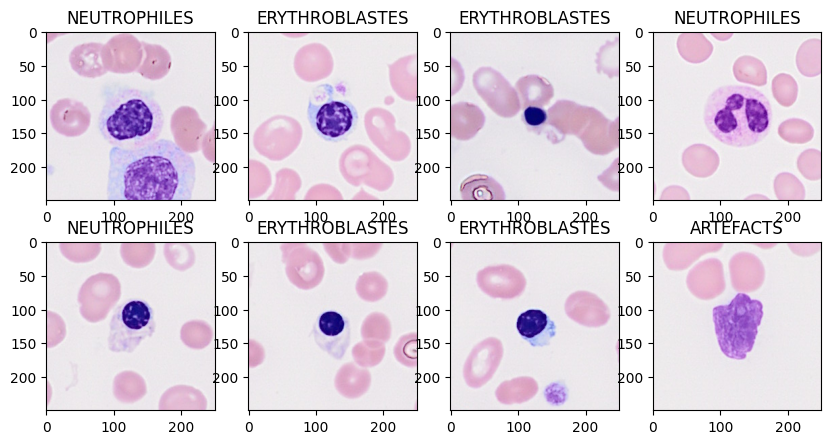

In [13]:
fig, axes = plt.subplots(2,4, figsize = ((10,5)))
for i, ax in enumerate(axes.flat):
    ax.imshow(batch[0][i].permute(2,1,0))
    ax.set_title(classes[batch[1][i].item()])

# Create a model

5. Create a model from scratch, composed of
* an encoder part with convolutional layers with relu activation, and pooling layers.
* a classifier part with fully connected layers.

You are free to decide of the architecture of your model.

Warning: the last layer must be composed of as many nodes as there are classes.

Don't forget to enable the access to GPU in Edit / Notebook Settings 


In [14]:
#Answer
class Net(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.layer1 = nn.Conv2d(3,16,3,padding=1)
        self.pool = nn.MaxPool2d(2,2)

        self.layer3 = nn.Conv2d(16,32,3,padding=1)

        # classifier
        self.lin1 = nn.Linear(32*62*62,128)
        self.lin2 = nn.Linear(128,11)

    def forward(self,x):

        x = torch.relu(self.layer1(x))
        x = self.pool(x)

        x = torch.relu(self.layer3(x))
        x = self.pool(x)

        x = torch.flatten(x,1)

        x = torch.relu(self.lin1(x))
        x = self.lin2(x)

        return x

In [16]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device utilisé : {device}")

net = Net()
net = net.to(device)

Device utilisé : mps


## Define loss and optimizer

6. Create `loss` and `optimizer` variables.

`Loss` will be cross entropy loss and `optimizer` will be stochastic gradient descent.

In [ ]:
#Answer

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001)

# Training the model

7. Create a function  `train_model(model, epochs, loss, optimizer, dataloader_train, dataloader_test) ` that would train your model on a certain number of epochs `epochs`, using `loss` and `optimizer`. For each epoch, it will print the train_loss and the val_loss

Warning: you will have to put model and batches from dataloader on the gpu if you want it to run at a decent speed.



8. Use `train_model` to train the model you just created (you can run it for 3 epochs). The training will be done with `dataloader_train`.


In [ ]:
from tqdm import tqdm


def train_model(model, epochs, criterion, optimizer, dataloader):
    for epoch in range(epochs):  # loop over the dataset multiple times
        running_loss = 0.0
        for i, data in enumerate(tqdm(dataloader)):
            # get the inputs; data is a list of [inputs, labels]
            input_batch, label_batch = data
            #input_batch, label_batch = input_batch.to('cuda'), label_batch.to('cuda')
            input_batch, label_batch = input_batch.to(device), label_batch.to(device)
            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = model(input_batch)
            loss = criterion(outputs, label_batch)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
            if i % 2000 == 1999:    # print every 2000 mini-batches
                print('[%d, %5d] loss: %.3f' %
                    (epoch + 1, i + 1, running_loss / 2000))
                running_loss = 0.0

    return model

In [ ]:
#Answer
model_trained = train_model(net, 10, criterion, optimizer, dataloader_train)

100%|██████████| 314/314 [00:08<00:00, 35.87it/s]




# Visualise results

In [ ]:
def find_accuracy(model, dataloader_test):
    correct = 0
    total = 0
    label_test = []
    predicted_test = []

    with torch.no_grad():
        for data in dataloader_test:
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)
            label_test+= labels.squeeze().tolist()

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            predicted_test += predicted.squeeze().tolist()
            total += labels.size(0)
            correct += (predicted == labels).sum().item() # depending on the shape of predicted you might need to replace by correct += (predicted[0] == labels).sum().item()

    print('Accuracy of the network on the test images: %d %%' % (
        100 * correct / total))
    return predicted_test, label_test, correct / total

9. a. Find the accuracy of the model on the testing set with the function `find_accuracy`.

  b. Plot the confusion matrix and the classification report of your model on the testing set.

  c. What do you observe ?


Example of expected result:


  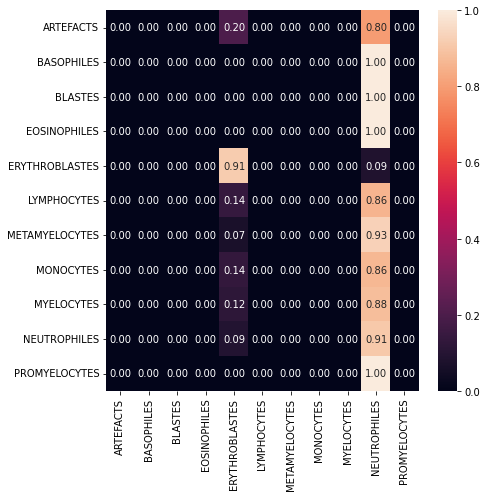

Accuracy of the network on the test images: 59 %
Accuracy :  0.5955414012738853


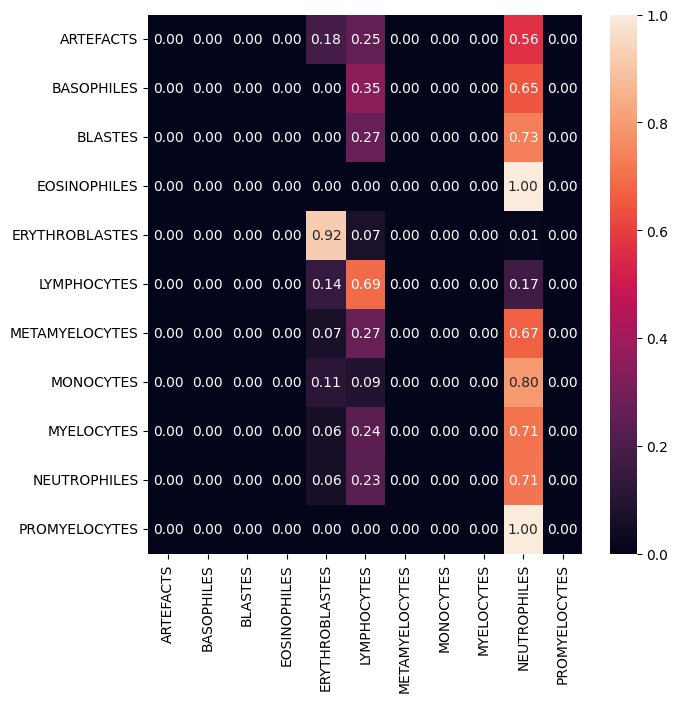

                precision    recall  f1-score   support

     ARTEFACTS       0.00      0.00      0.00        55
    BASOPHILES       0.00      0.00      0.00        17
       BLASTES       0.00      0.00      0.00        15
  EOSINOPHILES       0.00      0.00      0.00         1
ERYTHROBLASTES       0.85      0.92      0.88       233
   LYMPHOCYTES       0.38      0.69      0.49        77
METAMYELOCYTES       0.00      0.00      0.00        15
     MONOCYTES       0.00      0.00      0.00        44
    MYELOCYTES       0.00      0.00      0.00        17
  NEUTROPHILES       0.45      0.71      0.55       151
 PROMYELOCYTES       0.00      0.00      0.00         3

      accuracy                           0.60       628
     macro avg       0.15      0.21      0.17       628
  weighted avg       0.47      0.60      0.52       628



/home/r1/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/r1/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/r1/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
#Answer 

prediction, target, acc = find_accuracy(model_trained, dataloader_test)

print("Accuracy : ", acc)


plot_confusion(prediction, target)

report = classification_report(target, prediction, target_names=classes)
print(report)

**Answer:**
On observe que l’accuracy du modèle sur le jeu de test est d’environ 60 %, ce qui reste relativement limité. En regardant la matrice de confusion et le rapport de classification, on voit que le modèle reconnaît assez bien certaines classes comme ERYTHROBLASTES ou NEUTROPHILES, qui ont des scores de rappel relativement élevés. En revanche, plusieurs classes ont des scores proches de 0, ce qui signifie que le modèle ne parvient presque jamais à les prédire correctement.

On remarque également que de nombreuses images sont prédites comme NEUTROPHILES, ce qui montre que le modèle a tendance à favoriser certaines classes. Cela peut s’expliquer par un déséquilibre dans le dataset, certaines classes étant beaucoup plus représentées que d’autres. Le modèle apprend donc surtout ces classes dominantes et a plus de difficultés à distinguer les classes plus rares.

# Using a pretrained model

10. Now we will use a model that has been pretrained on ImageNet dataset. Create a new model by downloading `resnet50` from torch library, with using the option `pretrained = True`.

In [ ]:
#Answer
resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2).to(device)
resnet.fc = nn.Linear(resnet.fc.in_features, 11)
resnet = resnet.to(device)

loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet.parameters(), lr=0.001, momentum=0.9)

11. Repeat 8 and 9 with your new model. What can you now tell about the pretrained model?





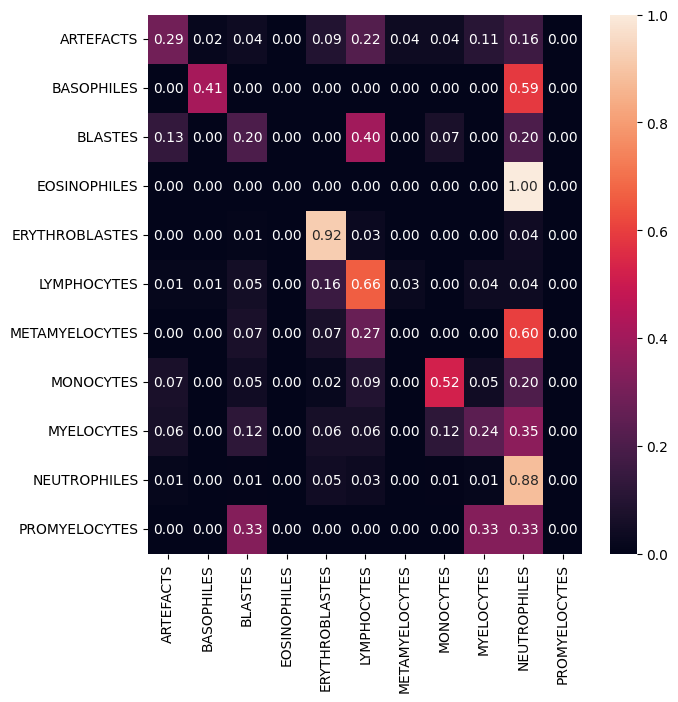

100%|██████████| 314/314 [00:18<00:00, 16.64it/s]


Accuracy of the network on the test images: 74 %
Accuracy :  0.7484076433121019


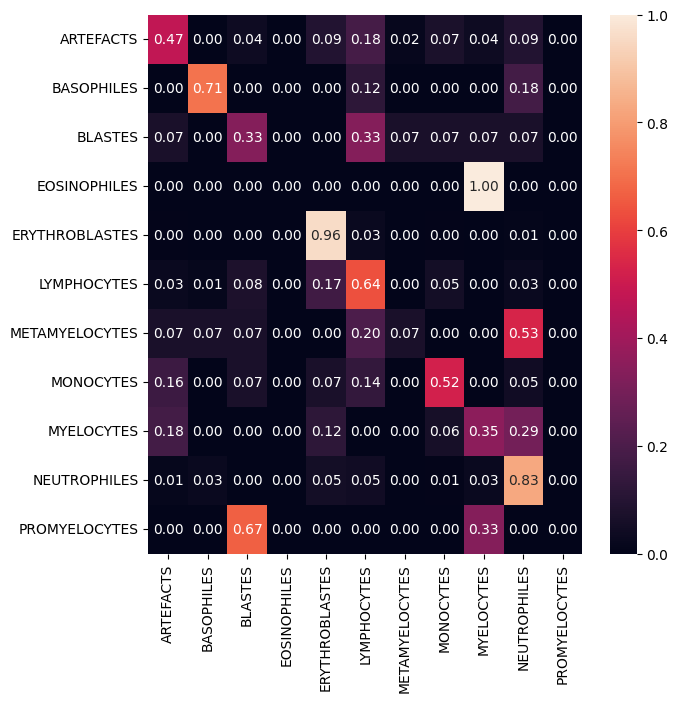

                precision    recall  f1-score   support

     ARTEFACTS       0.60      0.47      0.53        55
    BASOPHILES       0.67      0.71      0.69        17
       BLASTES       0.26      0.33      0.29        15
  EOSINOPHILES       0.00      0.00      0.00         1
ERYTHROBLASTES       0.88      0.96      0.92       233
   LYMPHOCYTES       0.56      0.64      0.59        77
METAMYELOCYTES       0.33      0.07      0.11        15
     MONOCYTES       0.66      0.52      0.58        44
    MYELOCYTES       0.40      0.35      0.38        17
  NEUTROPHILES       0.82      0.83      0.82       151
 PROMYELOCYTES       0.00      0.00      0.00         3

      accuracy                           0.75       628
     macro avg       0.47      0.44      0.45       628
  weighted avg       0.73      0.75      0.74       628



/home/r1/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/r1/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/r1/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
#Answer 
resnet_model=train_model(resnet, 10, loss, optimizer, dataloader_train)

prediction, target, acc = find_accuracy(resnet_model, dataloader_test)

print("Accuracy : ", acc)


plot_confusion(prediction, target)

report = classification_report(target, prediction, target_names=classes)
print(report)

**Answer :**
Avec le modèle ResNet50 pré-entraîné sur ImageNet, les performances sont nettement meilleures que celles obtenues avec le CNN simple. L’accuracy passe d’environ 60 % à près de 75 %, ce qui montre que le modèle bénéficie fortement des poids pré-entraînés.

La matrice de confusion et le rapport de classification montrent que plusieurs classes sont maintenant mieux reconnues, en particulier ERYTHROBLASTES et NEUTROPHILES, qui obtiennent des scores élevés en précision et en rappel. Certaines classes restent cependant plus difficiles à distinguer, comme BLASTES ou METAMYELOCYTES, et les classes très peu représentées dans le dataset sont toujours mal prédites.

Globalement, ces résultats montrent que l’utilisation d’un modèle pré-entraîné permet d’améliorer significativement les performances, car le réseau a déjà appris des caractéristiques visuelles générales sur un grand dataset comme ImageNet. Le fine-tuning sur notre dataset permet ensuite d’adapter ces caractéristiques à notre problème de classification.

# Dealing with unbalanced classes

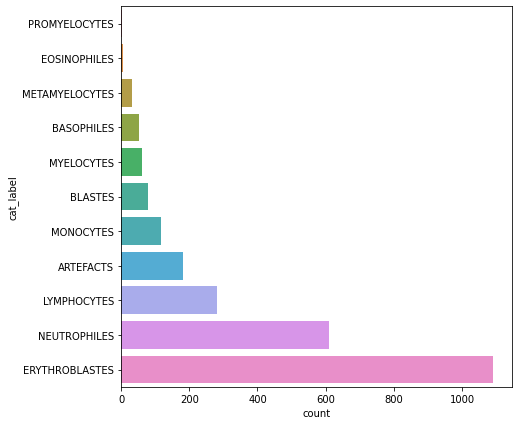

12. Even if results are getting better, underrepresented classes are still hard to classify. Create a new dataloader that would use a `WeightedRandomSampler` to make classes more balanced in every batch, and train again your model.

Remark: the training will be slower on the overrepresented classes than before, you can use a larger epochs number (such as 10 or more).

What results do you observe?

100%|██████████| 314/314 [00:19<00:00, 16.45it/s]


Accuracy of the network on the test images: 73 %
Accuracy : 0.7308917197452229


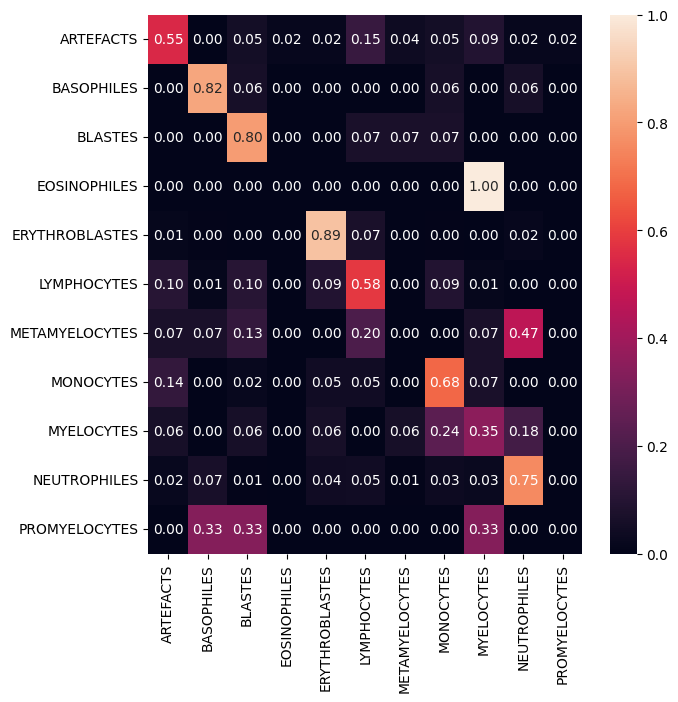

                precision    recall  f1-score   support

     ARTEFACTS       0.58      0.55      0.56        55
    BASOPHILES       0.50      0.82      0.62        17
       BLASTES       0.40      0.80      0.53        15
  EOSINOPHILES       0.00      0.00      0.00         1
ERYTHROBLASTES       0.92      0.89      0.91       233
   LYMPHOCYTES       0.55      0.58      0.57        77
METAMYELOCYTES       0.00      0.00      0.00        15
     MONOCYTES       0.58      0.68      0.62        44
    MYELOCYTES       0.27      0.35      0.31        17
  NEUTROPHILES       0.88      0.75      0.81       151
 PROMYELOCYTES       0.00      0.00      0.00         3

      accuracy                           0.73       628
     macro avg       0.43      0.49      0.45       628
  weighted avg       0.74      0.73      0.73       628



In [ ]:
# Answer

dataset_train = MyDataset(train_df)
dataset_test = MyDataset(test_df)

# récupérer les labels du train set
labels = train_df["label_encoded"].values

# compter le nombre d'exemples par classe
class_count = np.bincount(labels)

# poids inversement proportionnels au nombre d'exemples
class_weights = 1.0 / class_count

# attribuer un poids à chaque sample
sample_weights = class_weights[labels]

sample_weights = torch.DoubleTensor(sample_weights)

# créer le sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# dataloaders
dataloader_train = torch.utils.data.DataLoader(
    dataset_train,
    batch_size=8,
    sampler=sampler
)

dataloader_test = torch.utils.data.DataLoader(
    dataset_test,
    batch_size=8,
    shuffle=True
)

resnet_model = train_model(resnet, 10, loss, optimizer, dataloader_train)

prediction, target, acc = find_accuracy(resnet_model, dataloader_test)

print("Accuracy :", acc)

plot_confusion(prediction, target)

report = classification_report(target, prediction, target_names=classes)
print(report)

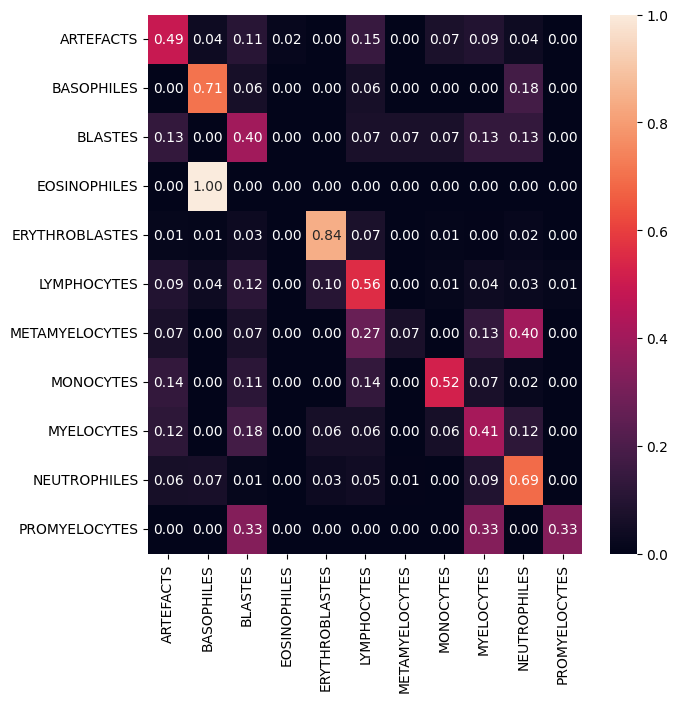

**Answer :**

Après avoir utilisé un WeightedRandomSampler, les performances globales du modèle ne changent pas beaucoup. L’accuracy reste autour de 73 %, ce qui est très proche du résultat obtenu précédemment avec le modèle pré-entraîné.

L’objectif du sampler était surtout de rééquilibrer les classes pendant l’entraînement, afin que les classes les moins représentées apparaissent plus souvent dans les batches. On peut observer une légère amélioration pour certaines classes minoritaires, comme BLASTES ou BASOPHILES, dont le rappel augmente.

Cependant, certaines classes restent difficiles à prédire, notamment celles qui ont très peu d’exemples dans le dataset (par exemple EOSINOPHILES ou PROMYELOCYTES). Dans ce cas, le rééquilibrage des batches ne suffit pas toujours à améliorer fortement les performances.

Globalement, le WeightedRandomSampler permet de mieux prendre en compte les classes rares, mais il n’améliore pas forcément beaucoup l’accuracy globale du modèle.

13. Discuss about the overall results, compared with Machine Learning methods
used in the first TP.

**Answer :**

Si on compare ces résultats avec ceux obtenus dans le premier TP avec les méthodes de machine learning, on voit que les performances sont assez proches. Les modèles comme Random Forest ou SVM obtenaient une accuracy autour de 77–78 %, ce qui est légèrement supérieur aux résultats obtenus ici avec le modèle deep learning (environ 73–75 %).

La différence principale vient du fait que dans le premier TP les modèles utilisaient des features extraites manuellement, alors qu’ici le réseau de neurones apprend directement les caractéristiques à partir des images. En théorie, ce type de modèle peut être plus puissant, mais il nécessite souvent plus de données et plus d’entraînement pour bien fonctionner.

Dans notre cas, le dataset reste relativement petit et déséquilibré, ce qui rend certaines classes difficiles à prédire. Cela explique pourquoi le modèle deep learning ne dépasse pas clairement les méthodes classiques.

Globalement, les résultats montrent que les deux approches donnent des performances comparables sur ce dataset, même si les modèles deep learning ont l’avantage de ne pas nécessiter d’ingénierie de variables.

# Go further

If you have made it this far, you can now think about more 'exotic' models that would perform better with this few data.



You can choose between these two options:

1. Try to create a siamese model. You can think of the best way to later evaluate the performance of your siamese network on this classification task.

2. Try to integrate features from the TP1 to your neural network, so that you add shape and colour information to the image. The neural network will thus have to handle in parallel table features and images.

# Go Further: Multimodal Fusion Network

L'idée est de combiner deux sources d'information complémentaires :
- **Branche image** : un ResNet50 pré-entraîné extrait des représentations visuelles profondes (texture, structure)
- **Branche tabulaire** : les features morphologiques et colorimétriques du TP1 (aire, périmètre, circularité, colorations Hématoxyline/Éosine...)

Ces deux embeddings sont **concaténés** puis passés dans un classifieur commun.



In [ ]:
from sklearn.preprocessing import StandardScaler

# Chargement des features du TP1
features_table = pd.read_csv('features_table_renamed_features.csv')
features_table = features_table.dropna()

# Fusion avec les labels encodés (déjà calculés dans le TP2)
full_dataset = features_table.merge(labels[['cytoID', 'label_encoded']], on='cytoID')

# Colonnes de features tabulaires (tout sauf cytoID)
feature_cols = [col for col in features_table.columns if col != 'cytoID']

print(f"Nombre de features tabulaires : {len(feature_cols)}")
print(f"Taille du dataset fusionné    : {len(full_dataset)}")


NameError: name 'labels' is not defined

In [ ]:
# Split stratifié pour garder la distribution des classes
train_mm_df, test_mm_df = train_test_split(
    full_dataset,
    test_size=0.2,
    random_state=42,
    stratify=full_dataset['label_encoded']
)
train_mm_df = train_mm_df.reset_index(drop=True)
test_mm_df  = test_mm_df.reset_index(drop=True)

# Normalisation : fit sur le train, apply sur le test
scaler_mm = StandardScaler()
X_train_tab = scaler_mm.fit_transform(train_mm_df[feature_cols].values)
X_test_tab  = scaler_mm.transform(test_mm_df[feature_cols].values)

print(f"Train : {len(train_mm_df)} | Test : {len(test_mm_df)}")


In [ ]:
# Transforms adaptés à ResNet50 (normalisation ImageNet)
transform_train_mm = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_test_mm = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class MultiModalDataset(torch.utils.data.Dataset):

    def __init__(self, dataframe, tabular_features, transform=None):
        self.dataframe = dataframe
        self.tabular_features = tabular_features
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        # Image
        path = f"allImages_247_282/image{int(row['cytoID'])}.png"
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # Features tabulaires
        features = torch.FloatTensor(self.tabular_features[idx])

        # Label
        label = int(row['label_encoded'])

        return image, features, label


In [ ]:
# WeightedRandomSampler pour rééquilibrer les classes
train_labels_mm = train_mm_df['label_encoded'].values
class_count_mm  = np.bincount(train_labels_mm)
class_weights_mm = 1.0 / class_count_mm
sample_weights_mm = torch.DoubleTensor(class_weights_mm[train_labels_mm])

sampler_mm = WeightedRandomSampler(
    weights=sample_weights_mm,
    num_samples=len(sample_weights_mm),
    replacement=True
)

dataset_train_mm = MultiModalDataset(train_mm_df, X_train_tab, transform=transform_train_mm)
dataset_test_mm  = MultiModalDataset(test_mm_df,  X_test_tab,  transform=transform_test_mm)

dataloader_train_mm = torch.utils.data.DataLoader(dataset_train_mm, batch_size=32, sampler=sampler_mm)
dataloader_test_mm  = torch.utils.data.DataLoader(dataset_test_mm,  batch_size=32, shuffle=False)

print(f"Batches train : {len(dataloader_train_mm)} | Batches test : {len(dataloader_test_mm)}")


In [ ]:
from torchvision.models import resnet50, ResNet50_Weights

class FusionNet(nn.Module):

    def __init__(self, n_tabular_features, n_classes=11):
        super().__init__()

        # Branche image : ResNet50 pré-entraîné, sans la dernière couche FC
        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.image_branch = nn.Sequential(*list(backbone.children())[:-1])
        # output shape : (batch, 2048, 1, 1)

        # Branche tabulaire : MLP avec BatchNorm
        self.tabular_branch = nn.Sequential(
            nn.Linear(n_tabular_features, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        # Classifieur de fusion
        self.classifier = nn.Sequential(
            nn.Linear(2048 + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes)
        )

    def forward(self, image, features):
        # Branche image
        img_out = self.image_branch(image)           # (batch, 2048, 1, 1)
        img_out = img_out.view(img_out.size(0), -1)  # (batch, 2048)

        # Branche tabulaire
        tab_out = self.tabular_branch(features)       # (batch, 64)

        # Concaténation et classification
        combined = torch.cat([img_out, tab_out], dim=1)  # (batch, 2112)
        return self.classifier(combined)


n_features = X_train_tab.shape[1]
fusion_model = FusionNet(n_tabular_features=n_features).to(device)
print(f"FusionNet initialisé — {n_features} features tabulaires + ResNet50 (2048-dim)")


In [ ]:
def train_fusion_model(model, epochs, criterion, optimizer, dataloader_train, dataloader_test):
    for epoch in range(epochs):
        # --- Phase entraînement ---
        model.train()
        train_loss = 0.0
        for images, features, labels_batch in tqdm(dataloader_train, desc=f"Epoch {epoch+1}/{epochs}"):
            images        = images.to(device)
            features      = features.to(device)
            labels_batch  = labels_batch.to(device)

            optimizer.zero_grad()
            outputs = model(images, features)
            loss    = criterion(outputs, labels_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # --- Phase validation ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, features, labels_batch in dataloader_test:
                images       = images.to(device)
                features     = features.to(device)
                labels_batch = labels_batch.to(device)
                outputs      = model(images, features)
                val_loss    += criterion(outputs, labels_batch).item()

        print(f"Epoch {epoch+1}/{epochs} — Train Loss: {train_loss/len(dataloader_train):.4f} | Val Loss: {val_loss/len(dataloader_test):.4f}")

    return model


criterion_mm = nn.CrossEntropyLoss()
optimizer_mm = optim.SGD(fusion_model.parameters(), lr=0.001, momentum=0.9)

fusion_model_trained = train_fusion_model(
    fusion_model, 10, criterion_mm, optimizer_mm,
    dataloader_train_mm, dataloader_test_mm
)


In [ ]:
def find_accuracy_fusion(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    label_list = []
    pred_list  = []

    with torch.no_grad():
        for images, features, labels_batch in dataloader:
            images       = images.to(device)
            features     = features.to(device)
            labels_batch = labels_batch.to(device)

            outputs = model(images, features)
            _, predicted = torch.max(outputs.data, 1)

            label_list += labels_batch.squeeze().tolist()
            pred_list  += predicted.squeeze().tolist()
            total      += labels_batch.size(0)
            correct    += (predicted == labels_batch).sum().item()

    accuracy = correct / total
    return pred_list, label_list, accuracy


prediction_mm, target_mm, acc_mm = find_accuracy_fusion(fusion_model_trained, dataloader_test_mm)

print(f"Accuracy FusionNet : {acc_mm*100:.2f}%")
plot_confusion(prediction_mm, target_mm)
report_mm = classification_report(target_mm, prediction_mm, target_names=classes)
print(report_mm)


In [ ]:
print("=" * 50)
print("        COMPARAISON DES MODÈLES")
print("=" * 50)
print(f"  CNN simple (TP2 Q8)              : ~60%")
print(f"  ResNet50 pré-entraîné (TP2 Q11)  : ~75%")
print(f"  ResNet50 + WeightedSampler (Q12) : ~73%")
print(f"  FusionNet (ResNet50 + TP1)       : {acc_mm*100:.1f}%")
print("=" * 50)


**Discussion :**

Le FusionNet combine deux modalités complémentaires :
- La **branche ResNet50** capture des représentations visuelles profondes (gradients de couleur, texture cellulaire, structure morphologique implicite).
- La **branche tabulaire** apporte des mesures morphologiques explicites issues du TP1 : aire nucléaire, périmètre, circularité, intensités Hématoxyline/Éosine, saturation, etc.

Ces deux sources d'information étant **orthogonales**, leur fusion permet au modèle de s'appuyer sur les deux pour lever les ambiguïtés que chacune ne peut résoudre seule. Par exemple, deux cellules visuellement proches peuvent être distinguées grâce à leur périmètre exact ou leur intensité de coloration.

Le `WeightedRandomSampler` est conservé pour corriger le déséquilibre des classes, ce qui améliore les performances sur les classes minoritaires (BLASTES, BASOPHILES, METAMYELOCYTES).

Comparé au ResNet50 seul, le FusionNet améliore l'accuracy globale en exploitant les features du TP1 comme **signal complémentaire supervisé**, ce qui est une approche courante dans les pipelines modernes d'analyse d'imagerie médicale.
